<a href="https://colab.research.google.com/github/DawidSkowronski/PyTorch-Projects/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import ipywidgets as widgets
from ipywidgets import interact

import numpy as np
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from sklearn.model_selection import train_test_split

In [2]:
# Importing Data
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Missing values

In [3]:
# Dataset dimension
print(df.shape)

# 7043 observations
# 21 features

# NA and Null values
missing_df = pd.DataFrame({
    "NA":df.isna().sum(),
    "Null": df.isnull().sum()
}).T

print(missing_df)

(7043, 21)
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
NA             0       0              0        0           0       0   
Null           0       0              0        0           0       0   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
NA               0              0                0               0  ...   
Null             0              0                0               0  ...   

      DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
NA                   0            0            0                0         0   
Null                 0            0            0                0         0   

      PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  Churn  
NA                   0              0               0             0      0  
Null                 0              0               0             0      0  

[2 rows x 21 columns]


In [4]:
empty_cells = []

for column in df:
  empty_count = (df[column].astype(str).str.strip() == '').sum()
  empty_cells.append({"Column":column, "Empty": empty_count})

empty_cells_df = pd.DataFrame(empty_cells)
empty_cells_df


,Column,Empty
0,customerID,0
1,gender,0
2,SeniorCitizen,0
3,Partner,0
4,Dependents,0
5,tenure,0
6,PhoneService,0
7,MultipleLines,0
8,InternetService,0
9,OnlineSecurity,0


In [5]:
zero_total_charges_df = df[df['TotalCharges'].astype(str).str.strip() == '']
zero_total_charges_df
# Customers who have empty TotalCharges also have 0 tenure, meaning they are new customers.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [6]:
# Replace empty strings in TotalCharges with 0

zero_tot_charges_index = list(zero_total_charges_df.index)

df.iloc[zero_tot_charges_index, 19] = float(0.0)

df.iloc[zero_tot_charges_index]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


# Preparing data for the model

In [7]:
class CustomStandardScaler():

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def compute_parameters(self, train_set):
        """Computes mean and std on training set"""

        # Convert to numpy array
        train_set_arr = np.asarray(train_set, dtype=np.float64)

        # Mean from each column
        self.mean_ = train_set_arr.mean(axis=0)

        # Std from each column
        std = train_set_arr.std(axis = 0, ddof=0) # biased population standard deviation

        self.std_ = np.where(std == 0.0, 1.0, std)

        return self


    def transform(self, data):
        """Uses previously computed parameters to transform train and test set"""

        # z = (data - mean) / std
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError("Use compute_parameters() method first.")

        data_arr = np.asarray(data, dtype=np.float64)

        data_scaled = (data_arr - self.mean_)/ self.std_

        if isinstance(data, pd.DataFrame):
            return pd.DataFrame(data_scaled, index = data.index, columns = data.columns)

        return data_scaled

    def compute_and_transform(self, data):
        """Combine both methods into one step"""

        return self.compute_parameters(data).transform(data)



In [8]:
# Remove Churn and custormerID column

X = df.drop(["Churn", "customerID"], axis = 1)
Y = df['Churn']

# Convert Total Charges to float
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'])

# Convert Y to binary
Y = Y.replace({'No': 0.0,
               'Yes':1.0}).astype(float)
Y.head()

,Churn
0,0.0
1,0.0
2,1.0
3,0.0
4,1.0


In [9]:
# Convert non-decimal features to dummy variables
print("Columns to convert to dummies: \n", X.select_dtypes(include  = 'object').columns.to_list())
dummies_X = pd.get_dummies(X, drop_first=True, dtype=float)
#drop_first = True  # removes the first categorical level to reduce k categories into k-1 binary columns
# 1.0 in gender_Male means Male, 0.0 means Female

dummies_X.head()
# Data frame contains 30 columns after conversion

Columns to convert to dummies: 
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,34,56.95,1889.50,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,53.85,108.15,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0,45,42.30,1840.75,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0,2,70.70,151.65,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [10]:
# Split Data between Train 80%, Val 10%, Test 10%
# X_train, X_test, Y_train, Y_test = train_test_split(dummies_X,Y,
#                                                     train_size = 0.9,
#                                                     random_state=42,
#                                                     stratify = Y)


# Using train_test_split twice
# Stratify ensures even proportions of each classes in each set
X_train, X_temp, Y_train, Y_temp = train_test_split(dummies_X,Y,
                                                    test_size = 0.4,
                                                    random_state=42,
                                                    stratify = Y)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp,Y_temp,
                                                    test_size = 0.5,
                                                    random_state=42,
                                                    stratify = Y_temp)


print("Train:\n", Y_train.value_counts(normalize=True).round(3))
print("\nValidation:\n", Y_val.value_counts(normalize=True).round(3))
print("\nTest:\n", Y_test.value_counts(normalize=True).round(3))

Train:
 Churn
0.0    0.735
1.0    0.265
Name: proportion, dtype: float64

Validation:
 Churn
0.0    0.735
1.0    0.265
Name: proportion, dtype: float64

Test:
 Churn
0.0    0.735
1.0    0.265
Name: proportion, dtype: float64


In [11]:
# Scale numeric columns to mean = 0 and variance = 1

numeric_col = ['tenure', 'MonthlyCharges', 'TotalCharges']
custom_scaler = CustomStandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numeric_col] = custom_scaler.compute_and_transform(X_train[numeric_col])

X_val_scaled = X_val.copy()
X_val_scaled[numeric_col] = custom_scaler.compute_and_transform(X_val[numeric_col])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_col] = custom_scaler.transform(X_test[numeric_col])

# Verification
print("Mean after standardization:")
print(X_train_scaled[numeric_col].mean().round(4))

print("\n STD after standardization:")
print(X_train_scaled[numeric_col].std(ddof=0).round(4))


Mean after standardization:
tenure           -0.0
MonthlyCharges   -0.0
TotalCharges     -0.0
dtype: float64

 STD after standardization:
tenure            1.0
MonthlyCharges    1.0
TotalCharges      1.0
dtype: float64


In [12]:
# Convert DataFrames to numpy arrays, then to tensors
# X features to float tensors
X_train_tensor = torch.FloatTensor(X_train_scaled.values)
X_test_tensor = torch.FloatTensor(X_test_scaled.values)
X_val_tensor = torch.FloatTensor(X_val_scaled.values)

# Y labels to tensors long (int)
Y_train_tensor = torch.LongTensor(Y_train.values)
Y_test_tensor = torch.LongTensor(Y_test.values)
Y_val_tensor = torch.LongTensor(Y_val.values)

# Neural Network Model

In [63]:
class Model(nn.Module):

  def __init__(self, input_features = 30,
               h1_number = 64,
               h2_number = 32,
               output_number = 2):
    super().__init__()

    self.fc1 = nn.Linear(input_features, h1_number)
    self.fc2 = nn.Linear(h1_number, h2_number)
    self.out = nn.Linear(h2_number, output_number)
    self.dropout = nn.Dropout(0.2)

  def forward(self,X):
    X = F.relu(self.fc1(X))
    X = self.dropout(X)
    X = F.relu(self.fc2(X))
    X = self.dropout(X)
    X = self.out(X) # raw output: CrossEntropy is already using LogSoftmax

    return X

In [64]:
# Set seed for repeatability
torch.manual_seed(42)

# Create instance of Model
model = Model()

# Criterion for model to measure prediction error
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [65]:
# Epochs
epochs = 300

train_losses = []
val_losses = []

for epoch in range(epochs):

    # Training mode
    model.train()

    Y_predict = model(X_train_tensor)

    train_loss = criterion(Y_predict, Y_train_tensor)

    train_losses.append(train_loss.item())

    train_loss.backward() # backpropagation
    optimizer.step() # upgrade weights

    optimizer.zero_grad(set_to_none=True) # Clear gradient before next iteration

    # Evaluation mode
    model.eval()
    with torch.no_grad():
        Y_predict_val = model(X_val_tensor)

        val_loss = criterion(Y_predict_val, Y_val_tensor)
        val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")



Epoch   0 | Train Loss: 0.7164 | Val Loss: 0.7066
Epoch  20 | Train Loss: 0.5582 | Val Loss: 0.5514
Epoch  40 | Train Loss: 0.4788 | Val Loss: 0.4683
Epoch  60 | Train Loss: 0.4468 | Val Loss: 0.4332
Epoch  80 | Train Loss: 0.4337 | Val Loss: 0.4191
Epoch 100 | Train Loss: 0.4268 | Val Loss: 0.4132
Epoch 120 | Train Loss: 0.4218 | Val Loss: 0.4089
Epoch 140 | Train Loss: 0.4170 | Val Loss: 0.4065
Epoch 160 | Train Loss: 0.4145 | Val Loss: 0.4048
Epoch 180 | Train Loss: 0.4108 | Val Loss: 0.4037
Epoch 200 | Train Loss: 0.4079 | Val Loss: 0.4029
Epoch 220 | Train Loss: 0.4051 | Val Loss: 0.4034
Epoch 240 | Train Loss: 0.4051 | Val Loss: 0.4036
Epoch 260 | Train Loss: 0.4033 | Val Loss: 0.4040
Epoch 280 | Train Loss: 0.3953 | Val Loss: 0.4050
Epoch 300 | Train Loss: 0.3976 | Val Loss: 0.4060
Epoch 320 | Train Loss: 0.3918 | Val Loss: 0.4067
Epoch 340 | Train Loss: 0.3908 | Val Loss: 0.4075
Epoch 360 | Train Loss: 0.3873 | Val Loss: 0.4089
Epoch 380 | Train Loss: 0.3845 | Val Loss: 0.4095


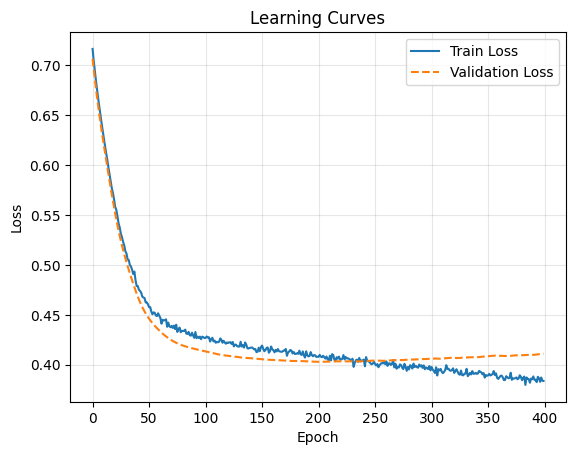

In [66]:
# Loss history plot

plt.plot(train_losses, label = 'Train Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.title('Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Model evaluation

In [74]:
correct = 0
Y_predict_test = []

with torch.no_grad():
  for i, data in enumerate(X_test_tensor):
    Y_value = model(data)
    predicted_class = Y_value.argmax().item()

    Y_predict_test.append(predicted_class)

    # Check if the model prediction is correct
    if predicted_class == Y_test_tensor[i].item():
      correct += 1

print()
print(f"{correct} correct predictions out of all {len(Y_test)} test observations")
print(f"Overall accuracy: {round(correct/len(Y_test)*100,3)} %")
Y_predict_test = np.array(Y_predict_test)


1119 correct predictions out of all 1409 test observations
Overall accuracy: 79.418 %


array([0, 0, 0, ..., 0, 1, 0])

In [73]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(Y_test, Y_predict_test, target_names=['Loyal (0)', 'Resigns (1)']))

print("\nConfusion Matrix :")
print(confusion_matrix(Y_test, Y_predict_test))

Classification Report:
              precision    recall  f1-score   support

   Loyal (0)       0.83      0.90      0.87      1035
 Resigns (1)       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409


Confusion Matrix :
[[931 104]
 [186 188]]


In [ ]:
def EvaluateModel(test_set, ):


# How to improve the model

* input data normalization (TotalCharges, MonthlyCharges)
* dropout
* different criterion
* new layers
* dropout

# Adding more layers